# Performing Shutdown Dose Rate Calculations

In this session, we'll learn how to calculate the Shutdown Dose Rate (SDR) for a very simple system. We will utilize [OpenMC's depletion capabilities](https://openmc.readthedocs.io/en/stable/) for performing SDR calculations using the Rigorous 2-Step (R2S) and Direct 1-Step (D1S) method. The R2S process allows one to calculate dose rate maps from the transport of radioactive decay products like gamma rays after a given irradiation scenario. The process couples an initial neutron transport simulation for computing flux spectrum integrated reaction rates for a defined spatial discretization to an inventory solver to compute nuclide inventories given an irradiation scenario. Once the new (radioactive) material compositions are computed, they are turned into photon sources based on the nuclear data contained in a depletion chain. These photon sources are then used for a second transport simulation to compute the dose rate at desired locations. In this tutorial, we will first walk through the steps manually for a cell-based R2S workflow to understand each piece. Then we will use the newly introduced `R2SManager` class to execute a mesh-based R2S workflow, followed by a D1S calculation of the same system.

### Task Outline for this tutorial
1. Build a steel slab activation model between a 14 MeV neutron source and a photon detector
2. Calculate volume-averaged fluxes and microscopic cross sections in the model for use in depletion
3. Define an irradiation scenario and solve the Bateman equations
4. Compute a photon source from the irradiated steel slab
5. Run a photon transport calculation to compute the decay photon flux at the detector location
6. As an alternative to steps 2–5, run a mesh-based R2S calculation using the `R2SManager` class
7. As an alternative to steps 2–5, run a D1S coupled neutron–photon calculation to compute the decay photon flux

In [1]:
import openmc
import openmc.deplete
from openmc.deplete import d1s
from math import pi
import numpy as np
from uncertainties import ufloat
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

## Task 1: Build steel slab activation model with detector
We will create a simple slab geometry irradiated by a monoenergetic, monodirectional 14 MeV point neutron source. On the opposite side of the slab we will create a detector to measure the photon dose rate. Our neutron source will be at the origin and be irradiating a 20cm x 20cm x 15cm slab of steel. Let's start by creating an OpenMC `Model` object and defining some basic variables for the geometry of the system.

In [2]:
model = openmc.Model()

We want the slab to extend from -10cm to +10cm in both $x$ and $y$ dimensions as well as from 1cm to 16cm in $z$. We also need to compute the volumes of each of these regions. For a more complicated system, we can run a stochastic volume calculation for each cell to get these values.

In [3]:
xmin = ymin = -10
xmax = ymax = 10
zmin = 1
zmax = 16
air_radius = 32
detector_z0 = 24
detector_radius = 1.5

Now we can create the surfaces necessary to build our model using some of the handy composite surface capabilities similar to MCNP "macrobodies".

In [4]:
rpp = openmc.model.RectangularParallelepiped(xmin, xmax, ymin, ymax, zmin, zmax)
detector_sphere = openmc.Sphere(z0=detector_z0, r=detector_radius)
boundary = openmc.Sphere(r=air_radius, boundary_type='vacuum')

Let's create a simple nickel-iron-chromium alloy with a little bit of manganese, molybdenum, and cobalt thrown in for a bit more spice to fill our slab. We also need to set the depletable attribute of the steel to let OpenMC know that this material should be considered during depletion calculations.

In [5]:
steel_comp = {
    'Fe': 69.9,
    'Ni': 10.0,
    'Cr': 15.0,
    'Mn': 2.0,
    'Mo': 3.0,
    'Co': 0.1,
}
steel = openmc.Material(name='steel')
steel.add_components(steel_comp, percent_type='wo')
steel.set_density('g/cm3', 8.0)
steel.depletable = True

When we get to the depletion portion of this tutorial we will need to assign a volume to the steel material. All materials that get depleted in OpenMC must meet two requirements:

`material.depletable = True` and their `volume` attribute must be set.

Let's create the `Cell` objects for our model and calculate their volumes.

In [9]:
slab = openmc.Cell(region=-rpp, fill=steel)
detector = openmc.Cell(region=-detector_sphere)
air = openmc.Cell(region=+rpp & +detector_sphere & -boundary)

We can use the bounding box property of the slab cell to get the volume

In [10]:
slab.volume = slab.bounding_box.volume
slab.fill.volume = slab.volume
detector.volume = 4/3*pi*detector_radius**3

In [11]:
model.geometry = openmc.Geometry([slab, detector, air])

So, we're happy with our geometry and materials, the only remaining need for our neutron transport simulation in support of shutdown dose rates is the neutron source and simulation settings. Let's create a simple, monoenergetic 14 MeV source pointing in the $z$-direction and run a fixed source simulation.

In [12]:
neutron_source = openmc.IndependentSource()
neutron_source.energy = openmc.stats.delta_function(14e6)
neutron_source.angle = openmc.stats.Monodirectional((0, 0, 1))
# source.space defaults to an openmc.stats.Point object located at the origin

model.settings.run_mode = 'fixed source'
model.settings.particles = 1000
model.settings.batches = 10
model.settings.source = neutron_source

Let's see a quick plot of the model with the source shown too:

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

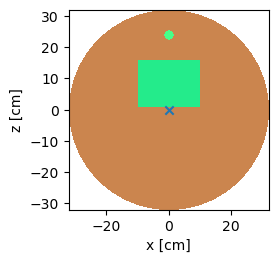

In [13]:
model.plot(n_samples=1, basis='xz')

## Task 2: Calculate volume-averaged fluxes and microscopic cross sections

In order to run a depletion calculation, we need to know the volume-average fluxes and microscopic reaction rates in the steel slab. OpenMC provides a function, `openmc.deplete.get_microxs_and_flux`, that will do this for you using the current simulation settings in the `Model` object that you pass it.

By default, this function will look at the currently configured depletion chain file (`openmc.config['chain_file']`) to determine which nuclides and reactions to collect reaction rates for. For activation purposes, we can construct a reduced chain that only includes nuclides that are "close" to our original set of nuclides. First, let's see what chain file is currently in use:

In [14]:
orig_chain_file = openmc.config['chain_file']
orig_chain_file

PosixPath('/Users/anovak/projects/cross_sections/endfb-vii.1-hdf5/depletion_chain.xml')

To get a list of nuclides present in our model, we can use the `get_all_nuclides` method on the `Geometry` class:

In [15]:
nuclides = model.geometry.get_all_nuclides()
nuclides

['Co59',
 'Cr50',
 'Cr52',
 'Cr53',
 'Cr54',
 'Fe54',
 'Fe56',
 'Fe57',
 'Fe58',
 'Mn55',
 'Mo100',
 'Mo92',
 'Mo94',
 'Mo95',
 'Mo96',
 'Mo97',
 'Mo98',
 'Ni58',
 'Ni60',
 'Ni61',
 'Ni62',
 'Ni64']

Next we need to create a `deplete.Chain` object from the existing file and then call the `reduce` method on it to create a simplified depletion chain.

In [20]:
full_chain = openmc.deplete.Chain.from_xml(orig_chain_file)
reduced_chain = full_chain.reduce(nuclides, level=2)
print(len(full_chain), len(reduced_chain))

3819 117


Finally, we need to write out the new chain to a file and set it in the data configuration.

In [21]:
reduced_chain.export_to_xml('chain_reduced.xml')
openmc.config['chain_file'] = 'chain_reduced.xml'

At this point, we can now call the `get_microxs_and_flux` function.

In [22]:
fluxes, micros = openmc.deplete.get_microxs_and_flux(model, [slab], run_kwargs={'output': False})

## Task 3: Define an irradiation scenario and deplete

With the volume-average fluxes and microscopic cross sections, we can create a depletion "operator" that returns reaction rates to a depletion "integrator". The operator class we will use is `openmc.deplete.IndependentOperator`, which task as arguments a `Materials` object (list of materials to deplete) and the fluxes and microscopic cross sections we obtained above. We also need to specifically tell the operator that reaction rates will be normalized based on a source rate, which can be done by passing `normalization_mode='source-rate'`.

In [23]:
operator = openmc.deplete.IndependentOperator([steel], fluxes, micros, normalization_mode='source-rate')

Now we can create the integrator. We'll use the most basic class, which is `PredictorIntegrator`. This class accepts as arguments the operator we just created and a list of timesteps and corresponding source rates. Let's start by creating those lists. For our irradiation scenario, we'll have 6 one-day pulses with a one-day cooling period between. Then we'll let the activated material cool for 30 days.

In [24]:
timesteps = [1.0, 1.0]*5 + [1.0, 30.0]  # days
source_rates = [1.0e12, 0.0]*5 + [1e12, 0.]

By default, the `PredictorIntegrator` class assumes the timesteps are in units of [s] but we can change this by specifying the `timestep_units` argument.

In [25]:
integrator = openmc.deplete.PredictorIntegrator(
    operator, timesteps, source_rates=source_rates, timestep_units='d'
)

To deplete the material now, we simply call the `integrate()` method on the integrator.

In [26]:
integrator.integrate()

[openmc.deplete] t=0.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=86400.0 s, dt=86400.0 s, source=0.0


/Users/anovak/miniforge/envs/moose/lib/python3.14/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=172800.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=259200.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=345600.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=432000.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=518400.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=604800.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=691200.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=777600.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=864000.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=950400.0 s, dt=2592000.0 s, source=0.0
[openmc.deplete] t=3542400.0 (final operator evaluation)


We see some information displayed for each timestep. Also notice that there is a "depletion_results.h5" file that has been created. This contains the results of the depletion simulation and can be used to determine activated material compositions.

In [27]:
results = openmc.deplete.Results('depletion_results.h5')
results

[<StepResult: t=0.0, dt=86400.0, source=1000000000000.0>,
 <StepResult: t=86400.0, dt=86400.0, source=0.0>,
 <StepResult: t=172800.0, dt=86400.0, source=1000000000000.0>,
 <StepResult: t=259200.0, dt=86400.0, source=0.0>,
 <StepResult: t=345600.0, dt=86400.0, source=1000000000000.0>,
 <StepResult: t=432000.0, dt=86400.0, source=0.0>,
 <StepResult: t=518400.0, dt=86400.0, source=1000000000000.0>,
 <StepResult: t=604800.0, dt=86400.0, source=0.0>,
 <StepResult: t=691200.0, dt=86400.0, source=1000000000000.0>,
 <StepResult: t=777600.0, dt=86400.0, source=0.0>,
 <StepResult: t=864000.0, dt=86400.0, source=1000000000000.0>,
 <StepResult: t=950400.0, dt=2592000.0, source=0.0>,
 <StepResult: t=3542400.0, dt=0.0, source=0.0>]

## Task 4: Compute a photon source from the irradiated steel slab

With the depletion results, we can get an irradiated material composition and determine its decay photon source. We begin with the `Results` object, which is list-like and stores a sequence of `StepResult` objects. Each `StepResult` object gives us information on material compositions at the corresponding point in time. To get the activated material composition after the 30 day cooling period, we just need to get the last `StepResult` object.

In [28]:
res = results[-1]

With this, we can now get an activated `Material` using the `get_material` method.

In [29]:
activated_material = res.get_material(str(steel.id))

We can see that this material includes both the original naturally occurring isotopes of Fe, Cr, etc., but now it also includes many radionuclides that were produced from activations.

In [30]:
activated_material.get_nuclides()[:10]

['H1', 'H2', 'He4', 'Ca44', 'Ca46', 'Ca47', 'Sc47', 'Sc49', 'Sc50', 'Ti46']

To get the spectra of decay photons from an activated material, we simply call the `get_decay_photon_energy` method.

In [31]:
energy_dist = activated_material.get_decay_photon_energy()
energy_dist

We see that this has given us a `Discrete` object, which represents a discrete probability distribution. However, instead of having probabilities that sum to unity, the probability for each discrete point represents the intensity in photons per second. To see what the spectrum looks like, let's plot it.

85


Text(0, 0.5, 'Intensity (photons/second)')

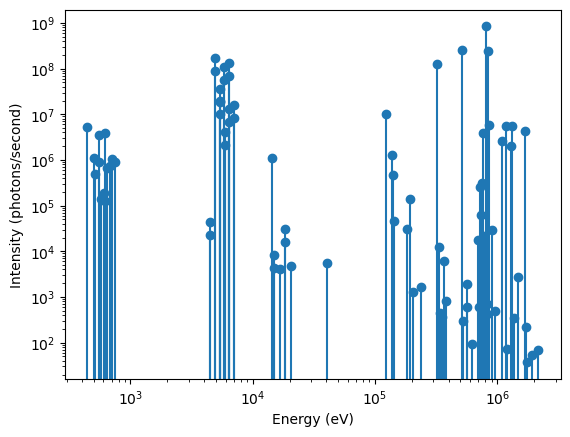

In [32]:
print(energy_dist.x.size)
fig, ax = plt.subplots()
ax.stem(energy_dist.x, energy_dist.p)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Intensity (photons/second)')

## Task 5: Run a photon transport calculation

With the decay photon spectrum, we can now define a new fixed source problem with a photon source in the slab. The spatial distribution should be uniform over the slab, isotropic in angle, and with an energy distribution corresponding to the decay photon spectrum. We also need to set the strength of the source to the integral of the energy distribution, as the source strength will serve as a normalization factor on tally results.

In [36]:
photon_source = openmc.IndependentSource()
photon_source.space = openmc.stats.Box(lower_left=slab.bounding_box.lower_left, upper_right=slab.bounding_box.upper_right)
photon_source.energy = energy_dist
photon_source.strength = energy_dist.integral()
photon_source.particle = 'photon'
model.settings.source = photon_source

For this demonstration, we'll simply determine the photon flux in the detector. If we wanted to compute the dose, we would need to use a flux-to-dose conversion factor with the help of the `EnergyFunctionFilter` class.

In [37]:
detector_tally = openmc.Tally()
detector_tally.filters = [openmc.CellFilter([detector]), openmc.ParticleFilter(['photon'])]
detector_tally.scores = ['flux']
model.tallies = [detector_tally]

Lastly, we can run the model and get the photon flux in the detector:

In [38]:
sp_file = model.run(output=False, apply_tally_results=True)
detector_tally.get_pandas_dataframe()

,cell,particle,nuclide,score,mean,std. dev.
0,5,photon,total,flux,2.690700e+06,1.700481e+06


## Task 6: Mesh-based R2S calculation

Now that we have manually gone through the steps to calculate the photon dose from a neutron irradiation, we will show how this can be dramatically simplified by using the `openmc.deplete.R2SManager` class, which automates the full workflow and works for either a cell-based or a mesh-based workflow.

The first step to use `R2SManager` is to define the domain that will be used as the activation region. For a mesh-based R2S calculation, that means we need to define a mesh. We'll use the convenient `RegularMesh.from_domain` classmethod for this:

In [29]:
mesh = openmc.RegularMesh.from_domain(slab, (5, 5, 5))

Before we proceed, let's reset the source on our model to our neutron source.

In [30]:
model.settings.source = neutron_source
model.settings.particles = 10_000

Now we're ready to create an instance of `R2SManager`

In [31]:
r2s = openmc.deplete.R2SManager(model, mesh)

Note that `R2SManager` gives us the opportunity to potentially use a different model for the photon transport calculation, but the default is to create a copy of the neutron model to be used for the photon model. This also allows us to separately change the settings/tallies for the photon transport calculation if we wish.

In [32]:
r2s.neutron_model.tallies = []
print(r2s.photon_model.tallies)

[Tally
	ID             =	3
	Name           =	
	Filters        =	CellFilter, ParticleFilter
	Nuclides       =	
	Scores         =	['flux']
	Estimator      =	None
	Multiply dens. =	True]


To run the R2S calculation, we have two options. Either we can call the three methods `step1_neutron_transport`, `step2_activation`, and `step3_photon_transport` separately, or we can simply call the `run` method which under the hood calls each of the "step" methods. We just need to give the irradiation timesteps and source rates to the `run` method.

In [33]:
r2s.run(timesteps, source_rates, timestep_units='d', photon_time_indices=[-1])

[openmc.deplete] t=0.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=86400.0 s, dt=86400.0 s, source=0.0


/home/romano/.pyenv/versions/3.13.5/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=172800.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=259200.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=345600.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=432000.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=518400.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=604800.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=691200.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=777600.0 s, dt=86400.0 s, source=0.0
[openmc.deplete] t=864000.0 s, dt=86400.0 s, source=1000000000000.0
[openmc.deplete] t=950400.0 s, dt=2592000.0 s, source=0.0


PosixPath('r2s_2025-11-19T10-01-21')

One of the nice features of the `R2SManager` class is that it encapsulates all input/output files in a timestamped directory each time it is run. It also has a `results` dictionary that contains all the results of the calculation. We can see what is stored there.

In [34]:
r2s.results.keys()

dict_keys(['mesh_material_volumes', 'fluxes', 'micros', 'activation_materials', 'depletion_results', 'photon_tallies'])

What we're interested in is the photon tally from the last timestep. Calling `r2s.results['photon_tallies']` will give us a dictionary keyed by the timestep index. To get the last timestep, we'll use index 12.

In [35]:
r2s.results['photon_tallies'][12]

[Tally
 	ID             =	3
 	Name           =	
 	Filters        =	CellFilter, ParticleFilter
 	Nuclides       =	total
 	Scores         =	['flux']
 	Estimator      =	tracklength
 	Multiply dens. =	True]

In [36]:
tally_result = r2s.results['photon_tallies'][12][0]
tally_result.get_pandas_dataframe()

,cell,particle,nuclide,score,mean,std. dev.
0,2,photon,total,flux,2.251189e+06,480072.473558


Let's also take a look at the meshed photon source by sampling it many times and taking a histogram of the resulting points.

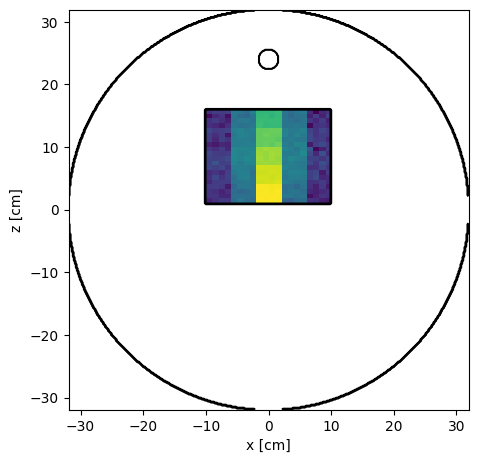

In [37]:
# Sample sites from the photon source
sites = r2s.photon_model.sample_external_source(100_000)

# Bin them onto a histogram
xs = [site.r[0] for site in sites]
zs = [site.r[2] for site in sites]
H, _, _ = np.histogram2d(xs, zs, 20, density=True)

# Plot the geometry
ax = r2s.photon_model.plot(basis='xz', pixels=(400, 400), outline='only')
ax.autoscale(False)
ax.imshow(H.T, extent=slab.bounding_box.extent['xz'], origin='lower', norm=LogNorm())

## Task 7: Calculate decay photon flux using D1S

The above calculation was done using a typical "rigorous 2-step" (R2S) workflow where we separately ran neutron transport, activation, and photon transport calculations. OpenMC also includes a built-in "direct 1-step" (D1S) method that relies on a coupled neutron–photon transport calculation with the use of time correction factors to compute the shutdown dose rate. The workflow for a D1S calculation is much simpler than for R2S and involves the following steps:

1. Indicate that neutron reactions should emit decay photons using `settings.use_decay_photons = True`
2. Make sure any "detector" tallies have a particle filter for photons
3. Call the `d1s.prepare_tallies` method on your model
4. Run the coupled neutron–photon transport simulation
5. Compute time correction factors with `d1s.time_correction_factors`
6. Apply the factors to the relevant tallies with `d1s.apply_time_correction`

Let's start by updating the model settings. We need to switch back to the neutron source, turn on photon transport and decay photon generation, update the number of particles per batch, and add the detector tally back to our model.

In [17]:
model.settings.source = neutron_source
model.settings.use_decay_photons = True
model.settings.photon_transport = True
model.settings.particles = 10_000
model.tallies = [detector_tally]

Now we'll use the `d1s.prepare_tallies` convenience function to update the tallies; specifically, this function will add one additional filter, the `ParentNuclideFilter` so that scores can be attributed to specific radionuclides (which is needed in order to apply time correction factors).

In [18]:
radionuclides = d1s.prepare_tallies(model)

Now with the tallies updated, we can run the model.

In [19]:
model.run(output=False, apply_tally_results=True)

PosixPath('/home/romano/workshops/openmc-nea-course/notebooks/dose/Solution/statepoint.10.h5')

Finally, we need to compute time correction factors and then apply them to the detector tally:

In [21]:
# Compute time correction factors
timesteps = [1.0, 1.0]*5 + [1.0, 30.0]  # days
source_rates = [1.0e12, 0.0]*5 + [1e12, 0.]
factors = d1s.time_correction_factors(radionuclides, timesteps, source_rates, timestep_units='d')

# and apply them to the tally
result = d1s.apply_time_correction(detector_tally, factors)

Finally, we can look at the result from the D1S method:

In [22]:
result.get_pandas_dataframe()

,cell,particle,nuclide,score,mean,std. dev.
0,2,photon,total,flux,2.588406e+06,601027.192559


We see that the decay photon flux computed by the D1S method is a bit lower than that calculated by the R2S method. This likely is due to spatial discretization error in the R2S method, whereby the averaging of the activation / decay photon source over the full slab results in an artifically higher decay photon source closer to the detector.